In [1]:
from torch.utils.data import DataLoader, Dataset
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import matplotlib.pyplot as plt
import os
from melbanks import LogMelFilterBanks
import pytorch_lightning as pl
import time
from torchmetrics.classification import BinaryAccuracy
from ptflops import get_model_complexity_info
import pandas as pd
from pytorch_lightning.loggers import CSVLogger

In [2]:
# from torchaudio.datasets import SPEECHCOMMANDS
# dataset = SPEECHCOMMANDS(root="./data", download=True, subset="testing")

In [3]:
class SpeechCommandsBinary(Dataset):
    def __init__(self, root, subset='training', device='cpu'):
        """
        root: путь к папке data
        subset: "training", "validation", "testing"
        device: "cpu" или "cuda"
        """
        self.root = root
        self.device = torch.device(device)
        self.label_map = {'yes': 0, 'no': 1}

        if subset == 'training':
            all_files = []
            for label in ['yes', 'no']:
                folder = os.path.join(root, label)
                for fname in os.listdir(folder):
                    if not self._in_list(fname, 'validation_list.txt') and \
                       not self._in_list(fname, 'testing_list.txt'):
                        all_files.append(os.path.join(folder, fname))
            file_list = all_files

        elif subset == 'validation':
            file_list = self._load_list('validation_list.txt')

        elif subset == 'testing':
            file_list = self._load_list('testing_list.txt')

        else:
            raise ValueError(f'Unknown subset {subset}')

        self.waveforms = []
        self.labels = []

        for path in file_list:
            waveform, sr = torchaudio.load(path)
            waveform = waveform.squeeze(0).to(self.device)

            label_name = path.split(os.sep)[-2]
            label = torch.tensor(self.label_map[label_name],
                                 device=self.device)

            self.waveforms.append(waveform)
            self.labels.append(label)

    def _in_list(self, filename, list_file):
        path = os.path.join(self.root, list_file)
        with open(path, 'r') as f:
            return any(filename == line.strip().split("/")[-1] for line in f)

    def _load_list(self, list_file):
        path = os.path.join(self.root, list_file)
        files = []
        with open(path, "r") as f:
            for line in f:
                line = line.strip()
                label = line.split('/')[0]
                if label in ['yes', 'no']:
                    files.append(os.path.join(self.root, line))
        return files

    def __len__(self):
        return len(self.waveforms)

    def __getitem__(self, idx):
        return self.waveforms[idx], self.labels[idx]

In [4]:
class CNN(nn.Module):
    def __init__(self, n_mels: int=40, groups: int=1):
        super().__init__()
        self.n_mels = n_mels

        self.conv1 = nn.Conv1d(n_mels, 64, 5, padding=2, groups=groups)
        self.conv2 = nn.Conv1d(64, 64, 5, padding=2, groups=groups)
        self.conv3 = nn.Conv1d(64, 32, 3, padding=1)

        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(32, 2)


    def forward(self, x):
        # x: (B, n_mels, T)
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = self.pool(x).squeeze(-1)
        return self.fc(x)

    def num_of_params(self):
        return sum(p.numel() for p in self.parameters())

    def compute_flops(self, time_frames: int=16000):
        '''
        :param time_frames: int
        :return: macs, params
        '''
        with torch.cuda.device(0):
            macs, params = get_model_complexity_info(
                self,
                (self.n_mels, time_frames),
                as_strings=True,
                print_per_layer_stat=False
            )
        return macs, params

In [37]:
class SpeechModel(pl.LightningModule):
    def __init__(self, n_mels=40, groups=1, lr=3e-4):
        super().__init__()
        self.save_hyperparameters()

        self.feature = LogMelFilterBanks(n_mels=n_mels)
        self.model = CNN(n_mels=n_mels, groups=groups)

        self.criterion = nn.CrossEntropyLoss()

        self.train_acc = BinaryAccuracy()
        self.val_acc = BinaryAccuracy()

    def print_info(self):
        macs, params = self.model.compute_flops()
        print(f"Macs: {macs}, Params: {params}, Groups: {self.hparams.groups}, N_mels: {self.hparams.n_mels}")

    def forward(self, x):
        x = self.feature(x)
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)

        preds = torch.argmax(logits, dim=1)
        acc = self.train_acc(preds, y)

        self.log('train_loss', loss, on_epoch=True, prog_bar=True, on_step=False)
        self.log('train_acc', acc, on_epoch=True, prog_bar=True, on_step=False)

        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)

        preds = torch.argmax(logits, dim=1)
        acc = self.val_acc(preds, y)

        self.log('val_loss', loss, on_epoch=True, prog_bar=True, on_step=False)
        self.log('val_acc', acc, on_epoch=True, prog_bar=True, on_step=False)

    def on_train_epoch_start(self):
        self.start_time = time.time()

    def on_train_epoch_end(self):
        epoch_time = time.time() - self.start_time
        self.log('epoch_time', epoch_time, prog_bar=True)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.lr)

In [6]:
train_ds = SpeechCommandsBinary('./data', 'training')
val_ds = SpeechCommandsBinary('./data', 'validation')
test_ds = SpeechCommandsBinary('./data', 'testing')

In [7]:
print(f'Train samples: {len(train_ds)}, Val samples: {len(val_ds)}, Test samples: {len(test_ds)}')
print(f'"Yes" samples: {len(os.listdir('./data/yes'))}, "No" samples: {len(os.listdir('./data/no'))}')

Train samples: 6358, Val samples: 803, Test samples: 824
"Yes" samples: 4044, "No" samples: 3941


In [8]:
TARGET_LEN = 16000

def fixed_length_collate(batch):
    waveforms, labels = zip(*batch)

    processed = []
    for w in waveforms:
        length = w.size(0)

        if length > TARGET_LEN:
            w = w[:TARGET_LEN]
        elif length < TARGET_LEN:
            w = F.pad(w, (0, TARGET_LEN - length))

        processed.append(w)

    waveforms = torch.stack(processed)
    labels = torch.tensor(labels, dtype=torch.long)

    return waveforms, labels

In [9]:
train_loader = DataLoader(train_ds, batch_size=64,
                          shuffle=True, num_workers=4, collate_fn=fixed_length_collate)
val_loader = DataLoader(val_ds, batch_size=64, collate_fn=fixed_length_collate)
test_loader = DataLoader(test_ds, batch_size=64, collate_fn=fixed_length_collate)

In [19]:
def plot_training_curves(log_dir):
    versions = [
        d for d in os.listdir(log_dir)
        if d.startswith("version_")
    ]

    if len(versions) == 0:
        raise ValueError(f"No versions found in {log_dir}")

    latest_version = sorted(
        versions,
        key=lambda x: int(x.split("_")[1])
    )[-1]

    metrics_path = os.path.join(log_dir, latest_version, "metrics.csv")
    print(f"Loading metrics from: {metrics_path}")

    metrics = pd.read_csv(metrics_path)
    metrics = metrics.dropna(subset=["epoch"])
    grouped = metrics.groupby("epoch").mean(numeric_only=True)

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    # ===== LOSS =====
    ax = axes[0]
    if "train_loss" in grouped:
        ax.plot(grouped["train_loss"])
    if "val_loss" in grouped:
        ax.plot(grouped["val_loss"])
    ax.set_title("Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend(["Train", "Validation"])
    ax.grid(True)

    # ===== ACCURACY =====
    ax = axes[1]
    if "train_acc" in grouped:
        ax.plot(grouped["train_acc"])
    if "val_acc" in grouped:
        ax.plot(grouped["val_acc"])
    ax.set_title("Accuracy")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.legend(["Train", "Validation"])
    ax.grid(True)

    # ===== EPOCH TIME =====
    ax = axes[2]
    if "epoch_time" in grouped:
        ax.plot(grouped["epoch_time"])
        ax.set_title("Epoch Time")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Seconds")
        ax.grid(True)
    else:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

In [41]:
def test_acc(model, device='cuda'):
    model.eval()
    model.to(device)
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            preds = torch.argmax(logits, dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    model.to('cpu')

    return correct / total

In [ ]:
logger = CSVLogger('logs', name='mels_20_groups_1')

model_mels20_groups1 = SpeechModel(n_mels=20, groups=1, lr=3e-4)

trainer = pl.Trainer(
    max_epochs=25,
    logger=logger,
    accelerator='auto',
)

trainer.fit(model_mels20_groups1, train_loader, val_loader)

In [ ]:
logger = CSVLogger('logs', name='mels_40_groups_1')

model_mels40_groups1 = SpeechModel(n_mels=40, groups=1, lr=3e-4)

trainer = pl.Trainer(
    max_epochs=25,
    logger=logger,
    accelerator='auto',
)

trainer.fit(model_mels40_groups1, train_loader, val_loader)

In [ ]:
logger = CSVLogger('logs', name='mels_80_groups_1')

model_mels80_groups1 = SpeechModel(n_mels=80, groups=1, lr=3e-4)

trainer = pl.Trainer(
    max_epochs=25,
    logger=logger,
    accelerator='auto',
)

trainer.fit(model_mels80_groups1, train_loader, val_loader)

Loading metrics from: logs/mels_20_groups_1/version_1/metrics.csv


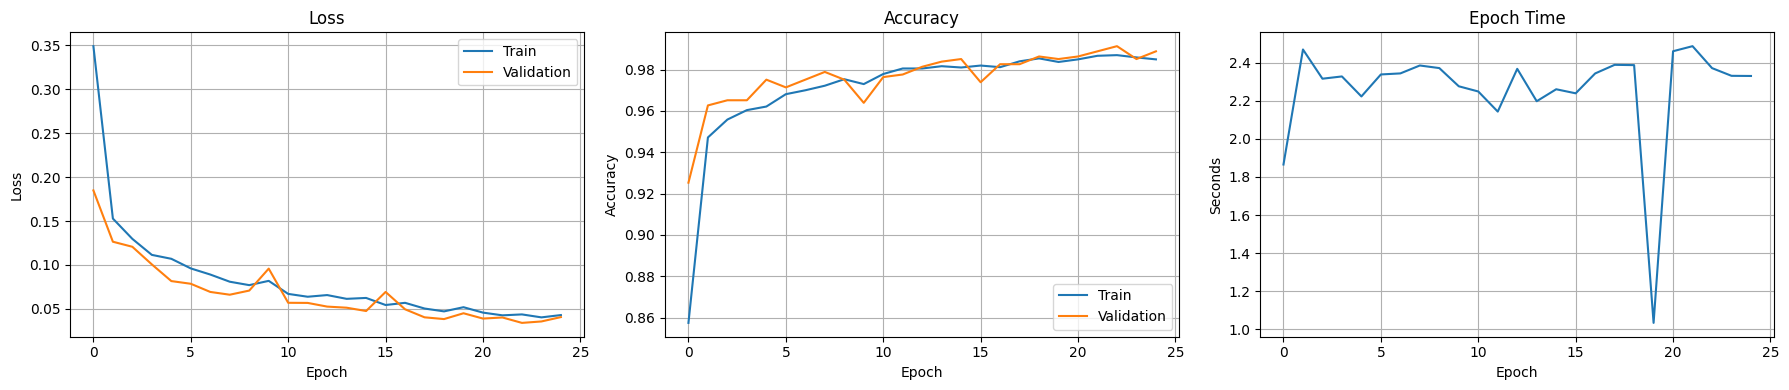

Macs: 534.53 MMac, Params: 33.25 k, Groups: 1, N_mels: 20
Test accuracy: 0.9854


In [42]:
plot_training_curves('logs/mels_20_groups_1')
model_mels20_groups1.print_info()
print(f'Test accuracy: {test_acc(model_mels20_groups1):.4f}')

Loading metrics from: logs/mels_40_groups_1/version_6/metrics.csv


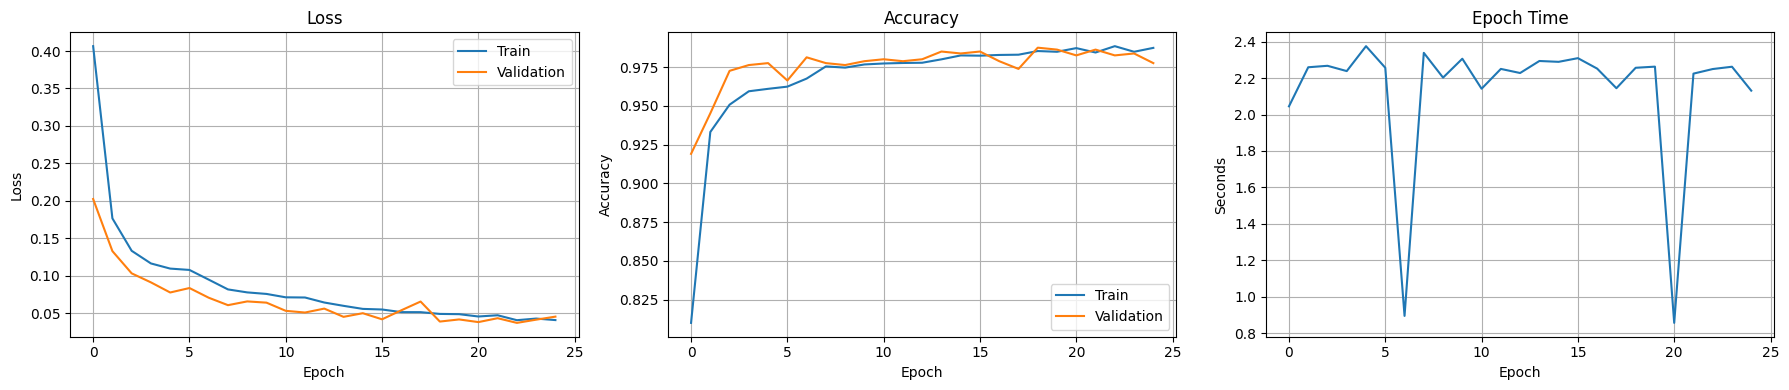

Macs: 636.93 MMac, Params: 39.65 k, Groups: 1, N_mels: 40
Test accuracy: 0.9842


In [43]:
plot_training_curves('logs/mels_40_groups_1')
model_mels40_groups1.print_info()
print(f'Test accuracy: {test_acc(model_mels40_groups1):.4f}')

Loading metrics from: logs/mels_80_groups_1/version_1/metrics.csv


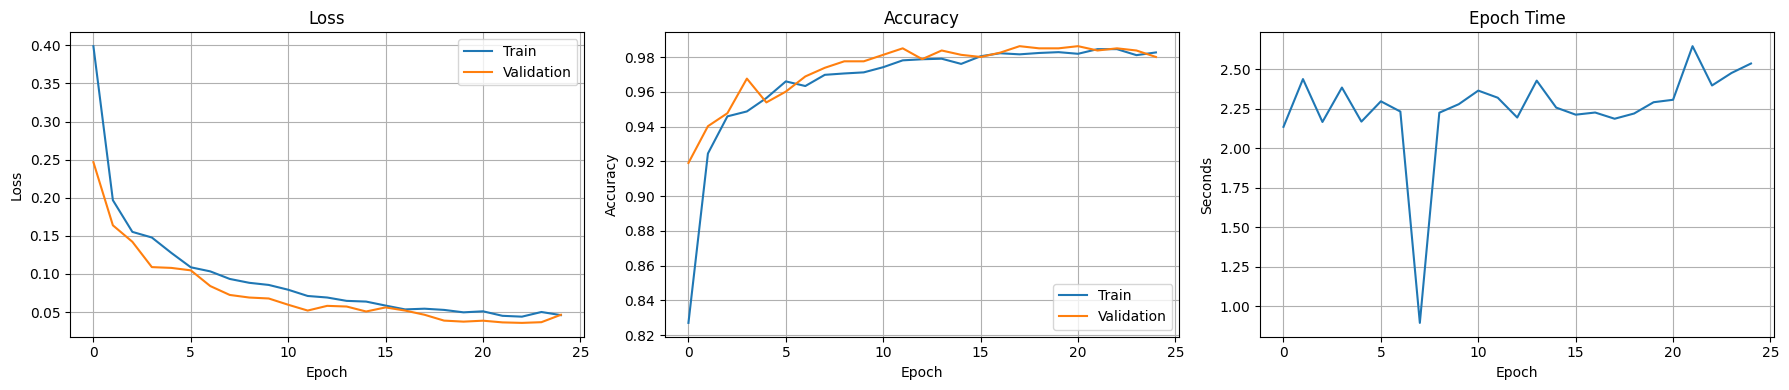

Macs: 841.73 MMac, Params: 52.45 k, Groups: 1, N_mels: 80
Test accuracy: 0.9806


In [44]:
plot_training_curves('logs/mels_80_groups_1')
model_mels80_groups1.print_info()
print(f'Test accuracy: {test_acc(model_mels80_groups1):.4f}')

In [ ]:
groups2model = {}
for groups in [2, 4, 8, 16]:
    logger = CSVLogger('logs', name=f'mels_80_groups_{groups}')

    model = SpeechModel(n_mels=80, groups=groups, lr=3e-4)
    groups2model[groups] = model

    trainer = pl.Trainer(
        max_epochs=25,
        logger=logger,
        accelerator='auto',
    )

    trainer.fit(model, train_loader, val_loader)

Loading metrics from: logs/mels_80_groups_2/version_0/metrics.csv


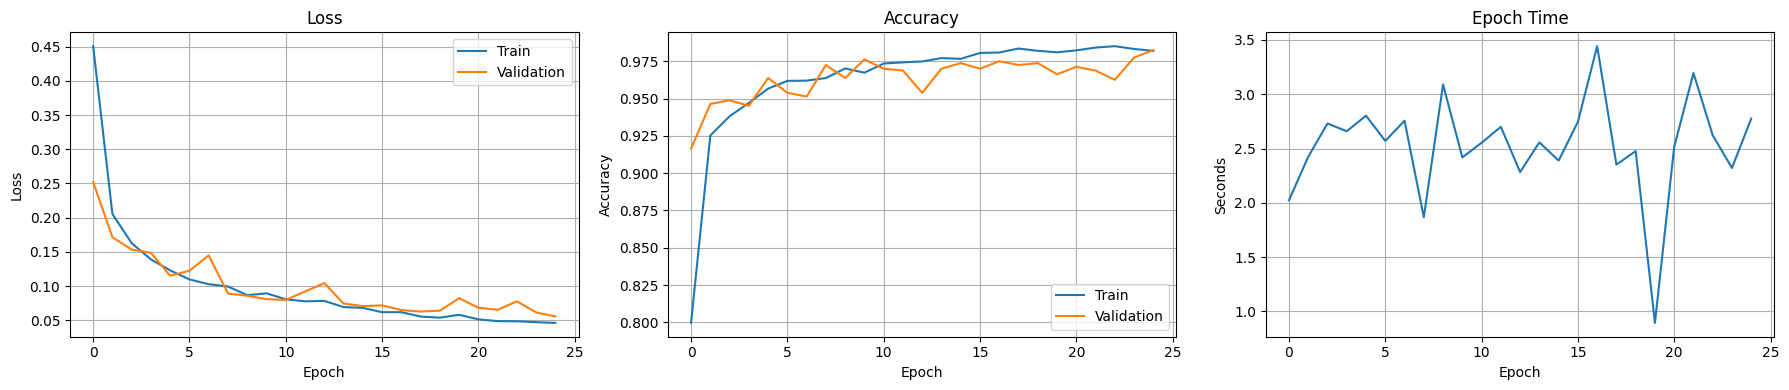

Macs: 473.09 MMac, Params: 29.41 k, Groups: 2, N_mels: 80
Test accuracy: 0.9842


In [45]:
plot_training_curves('logs/mels_80_groups_2')
groups2model[2].print_info()
print(f'Test accuracy: {test_acc(groups2model[2]):.4f}')

Loading metrics from: logs/mels_80_groups_4/version_0/metrics.csv


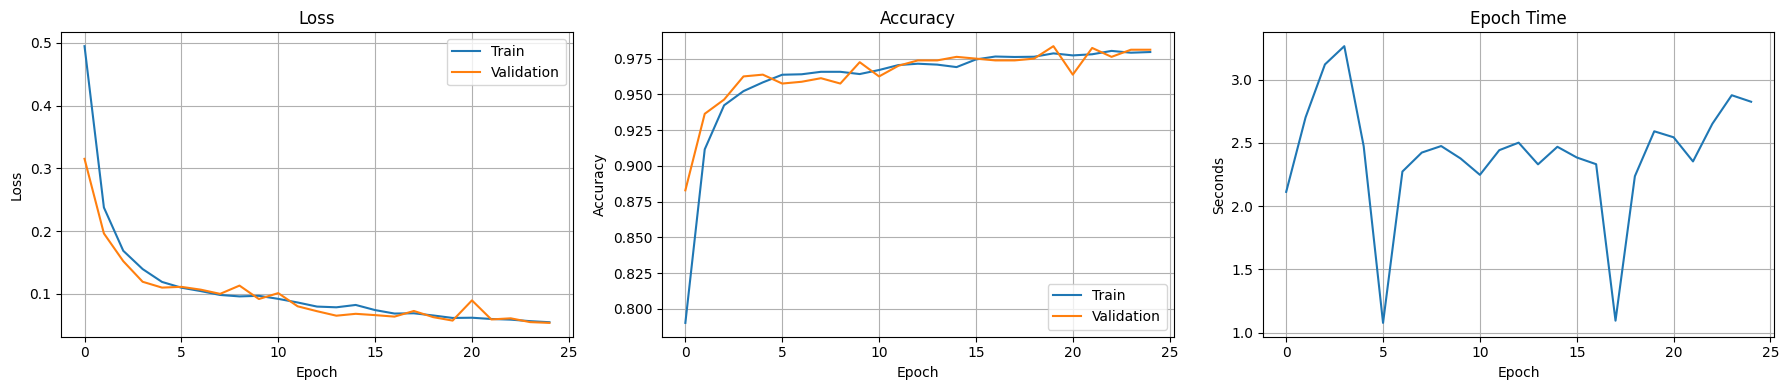

Macs: 288.77 MMac, Params: 17.89 k, Groups: 4, N_mels: 80
Test accuracy: 0.9769


In [46]:
plot_training_curves('logs/mels_80_groups_4')
groups2model[4].print_info()
print(f'Test accuracy: {test_acc(groups2model[4]):.4f}')

Loading metrics from: logs/mels_80_groups_8/version_0/metrics.csv


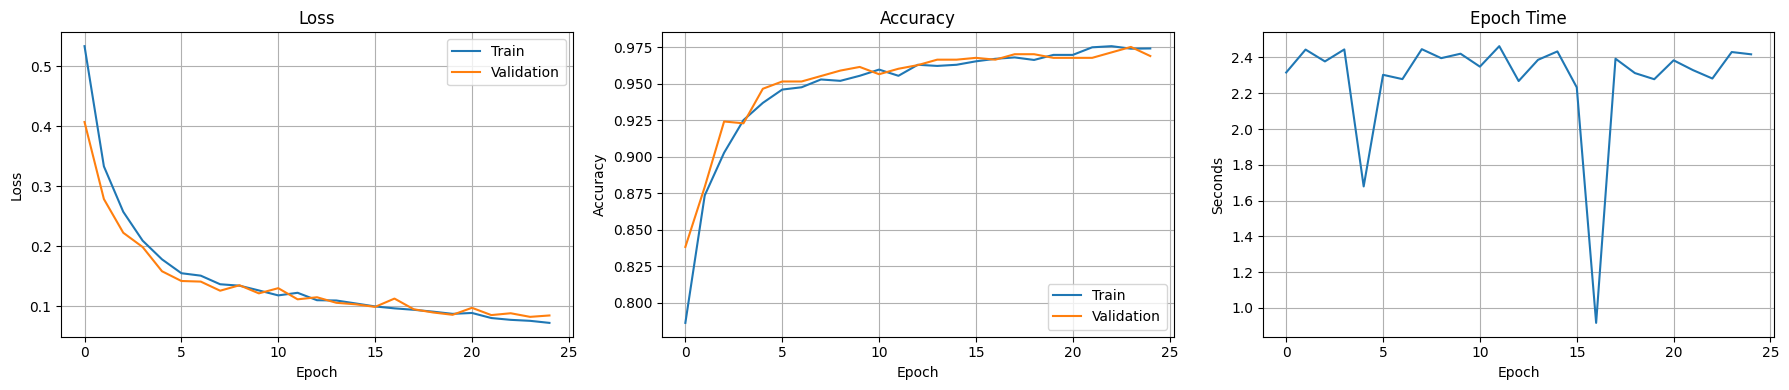

Macs: 196.61 MMac, Params: 12.13 k, Groups: 8, N_mels: 80
Test accuracy: 0.9733


In [47]:
plot_training_curves('logs/mels_80_groups_8')
groups2model[8].print_info()
print(f'Test accuracy: {test_acc(groups2model[8]):.4f}')

Loading metrics from: logs/mels_80_groups_16/version_0/metrics.csv


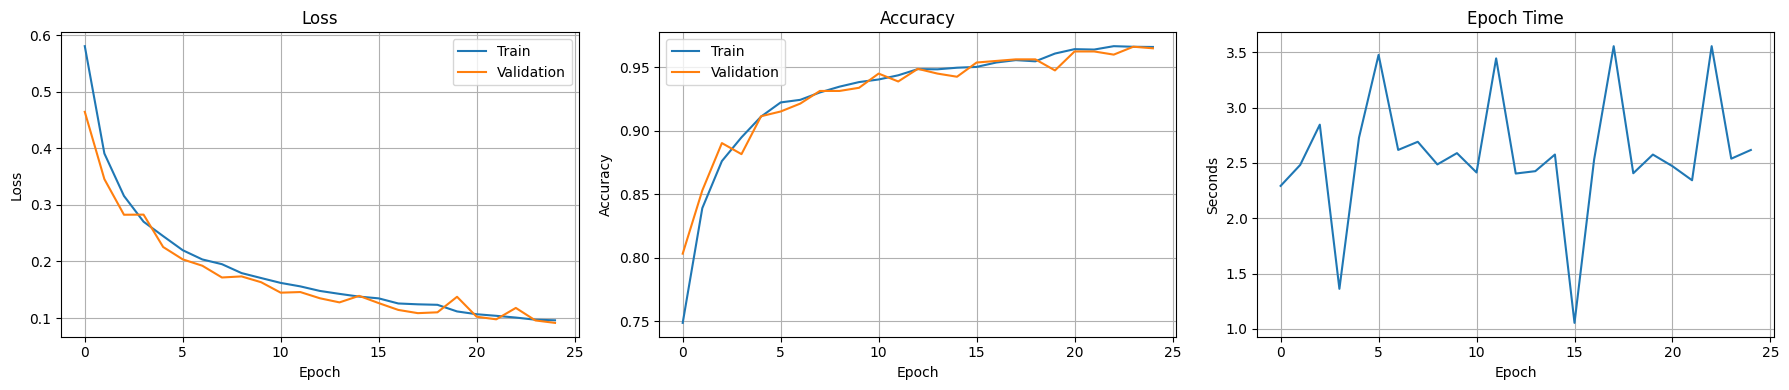

Macs: 150.53 MMac, Params: 9.25 k, Groups: 16, N_mels: 80
Test accuracy: 0.9709


In [48]:
plot_training_curves('logs/mels_80_groups_16')
groups2model[16].print_info()
print(f'Test accuracy: {test_acc(groups2model[16]):.4f}')

In [55]:
def plot_epoch_time_vs_groups(groups, log_root="logs", name_template="mels_80_groups_{}"):
    times = []

    for g in groups:
        log_dir = os.path.join(log_root, name_template.format(g))
        versions = [d for d in os.listdir(log_dir) if d.startswith("version_")]
        if not versions:
            print(f"No versions found for group={g}, skipping")
            continue
        latest_version = sorted(versions, key=lambda x: int(x.split("_")[1]))[-1]
        metrics_path = os.path.join(log_dir, latest_version, "metrics.csv")
        metrics = pd.read_csv(metrics_path)
        metrics = metrics.dropna(subset=["epoch"])
        grouped = metrics.groupby("epoch").mean(numeric_only=True)
        if "epoch_time" in grouped:
            avg_time = grouped["epoch_time"].mean()
            times.append(avg_time)
        else:
            times.append(None)
            print(f"No epoch_time in logs for group={g}")
    plt.figure(figsize=(6,4))
    plt.plot(groups, times, marker='o')
    plt.title("Average Epoch Time vs Groups")
    plt.xlabel("Groups")
    plt.ylabel("Epoch Time (s)")
    plt.grid(True)
    plt.show()

[np.float64(2.252157201766968), np.float64(2.526715259552002), np.float64(2.407721700668335), np.float64(2.2795958042144777), np.float64(2.5791217517852782)]


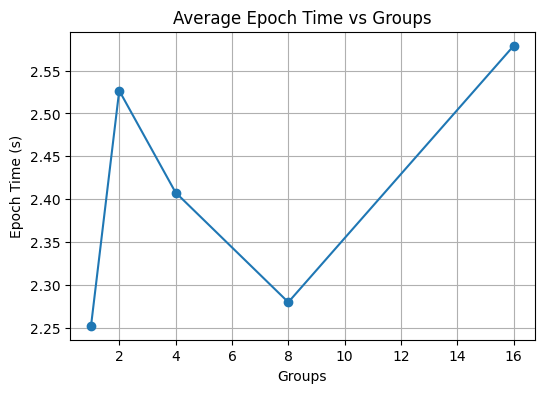

In [56]:
plot_epoch_time_vs_groups([1, 2, 4, 8, 16])

In [59]:
res_df = pd.DataFrame(columns=["Groups", "Params (k)", "Macs (M)", "Test Accuracy", "Epoch Time (s)"])
res_df.loc[len(res_df)] = [1, 52.45, 841.73, 0.9806, 2.252]
res_df.loc[len(res_df)] = [2, 29.41, 473.09, 0.9842, 2.527]
res_df.loc[len(res_df)] = [4, 17.89, 288.77, 0.9769, 2.408]
res_df.loc[len(res_df)] = [8, 12.13, 196.61, 0.9733, 2.28]
res_df.loc[len(res_df)] = [16, 9.25, 150.53, 0.9709, 2.579]

In [76]:
def plot_model_analysis(res_df):
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))

    # 1. Test Accuracy vs Groups
    axes[0,0].plot(res_df["Groups"], res_df["Test Accuracy"], marker='o', color='blue', label='Test Accuracy')
    axes[0,0].set_title("Test Accuracy vs Groups")
    axes[0,0].set_xlabel("Groups")
    axes[0,0].set_ylabel("Test Accuracy")
    axes[0,0].legend()

    # 2. Params и MACs vs Groups
    axes[0,1].plot(res_df["Groups"], res_df["Params (k)"], marker='o', color='green', label='Params (k)')
    axes[0,1].plot(res_df["Groups"], res_df["Macs (M)"], marker='o', color='red', label='MACs (M)')
    axes[0,1].set_title("Params и MACs vs Groups")
    axes[0,1].set_xlabel("Groups")
    axes[0,1].set_ylabel("Count")
    axes[0,1].legend()

    # 3. Accuracy vs Params (лог-шкала)
    axes[1,0].plot(res_df["Params (k)"], res_df["Test Accuracy"], marker='o', color='purple', label='Test Accuracy')
    axes[1,0].set_xscale('log')
    axes[1,0].set_title("Test Accuracy vs Params (k)")
    axes[1,0].set_xlabel("Params (k) [log scale]")
    axes[1,0].set_ylabel("Test Accuracy")

    # 4. Accuracy vs MACs (лог-шкала)
    axes[1,1].plot(res_df["Macs (M)"], res_df["Test Accuracy"], marker='o', color='orange', label='Test Accuracy')
    axes[1,1].set_xscale('log')
    axes[1,1].set_title("Test Accuracy vs MACs")
    axes[1,1].set_xlabel("MACs (M) [log scale]")
    axes[1,1].set_ylabel("Test Accuracy")

    plt.tight_layout()
    plt.show()

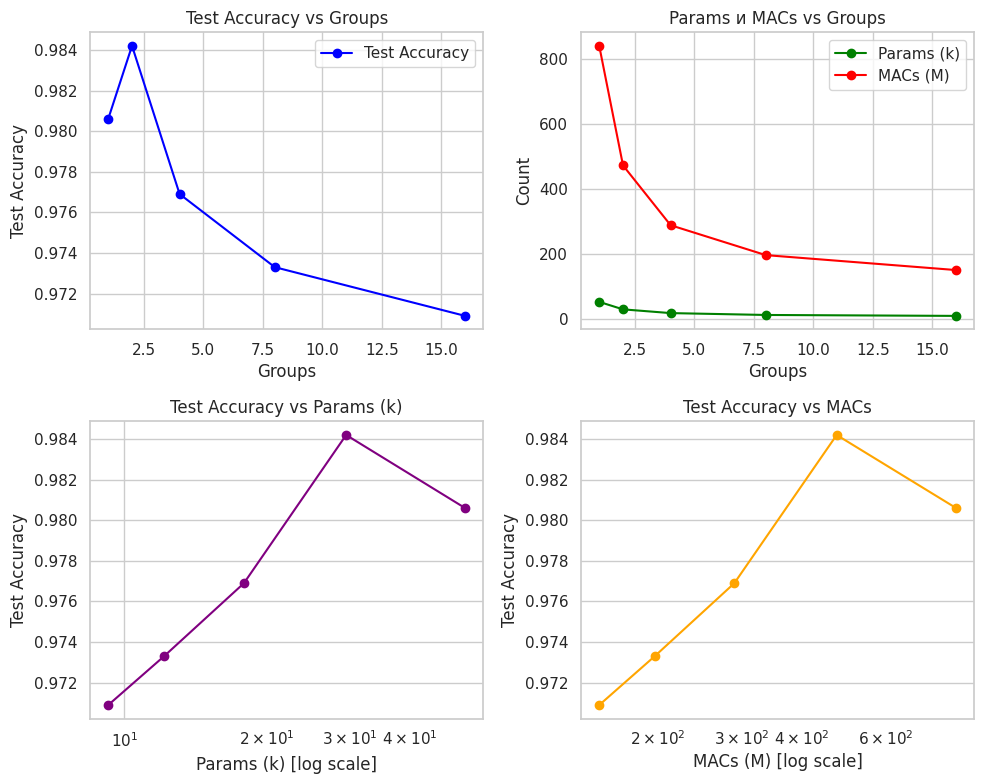

In [77]:
plot_model_analysis(res_df)